In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

%matplotlib widget

### Hamiltonian and pulse definition

In [2]:
rabi_extracted = np.load('./data/rabi_osc/lambda_values.npz', allow_pickle=True)

lambdas = rabi_extracted['lambdas']

lambdas

array([0.526, 0.621, 0.753])

In [3]:
# Define basis states
ket0 = qt.basis(5, 0)
ket1 = qt.basis(5, 1)
ket2 = qt.basis(5, 2)
ket3 = qt.basis(5, 3)

bra0 = ket0.dag()
bra1 = ket1.dag()
bra2 = ket2.dag()
bra3 = ket3.dag()

# Hamiltonian builder
def Hamiltonian(lambdas, delta, Delta):
    lambda_0 = lambdas[0]
    lambda_1 = lambdas[1]
    lambda_2 = lambdas[2]
    H0 = delta*ket1*bra1 + (2*delta-Delta)*ket2*bra2 + (3*delta-3*Delta)*ket3*bra3
    H1_dag = (lambda_0/2)*(ket1*bra0)
    H1 = (lambda_0/2)*(ket0*bra1)
    H2_dag = (lambda_1/2)*(ket2*bra1)
    H2 = (lambda_1/2)*(ket1*bra2)
    H3_dag = (lambda_2/2)*(ket3*bra2)
    H3 = (lambda_2/2)*(ket2*bra3)
    return H0, H1, H1_dag, H2, H2_dag, H3, H3_dag

# Pulse-level waveform description
def Omega_x(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            return pulse_specs['A'] * (np.exp(-(t_local-pulse_specs['tg']/2)**2/(2*pulse_specs['sigma']**2)) - np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) \
                        / (1-np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) # normalization part, truncated Gaussian amplitude will be pulse_specs['A]
    return 0

def Omega_y(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            tg = pulse_specs['tg']
            sigma = pulse_specs['sigma']
            A = pulse_specs['A']

            # Gaussian normalization
            norm = 1 - np.exp(-tg**2 / (8 * sigma**2))
            gauss = np.exp(-(t_local - tg/2)**2 / (2 * sigma**2))
            offset = np.exp(-tg**2 / (8 * sigma**2))

            G = A * (gauss - offset) / norm
            dG = -A * (t_local - tg/2) / sigma**2 * gauss / norm

            # Raised-cosine window
            w = 0.5 * (1 - np.cos(2 * np.pi * t_local / tg))
            dw = (np.pi / tg) * np.sin(2 * np.pi * t_local / tg)
            result = dG * w + G * dw
            result_scaled = pulse_specs['beta']*result
            return result_scaled
    return 0

def Omega(t, args):
    return Omega_x(t, args) - 1j*Omega_y(t, args)

def add_pulse(pulse_train, pulse_name, start, tg, sigma, A, beta):
    pulse_train[pulse_name] = {'start': start, 'tg': tg, 'sigma': sigma, 'A': A, 'beta': beta}
    pulse_train['clock'] += tg

In [ ]:
amp_uncorrected = 0.2512 # uncorrected pulse amplitude
beta_demo = 0.1
pulse_train = {'clock': 0}
add_pulse(pulse_train, pulse_name='Gaussian', start=pulse_train['clock'], tg=20, sigma=20/4, A=amp_uncorrected, beta=beta_demo)

times = np.linspace(0, 40, 100)
waveform_Gaussian = np.array([Omega_x(t, pulse_train) for t in times])
waveform_DRAG_1 = 1*np.gradient(waveform_Gaussian)
waveform_DRAG_2 = np.array([Omega_y(t, pulse_train) for t in times])
waveform_general = np.array([Omega(t, pulse_train) for t in times])

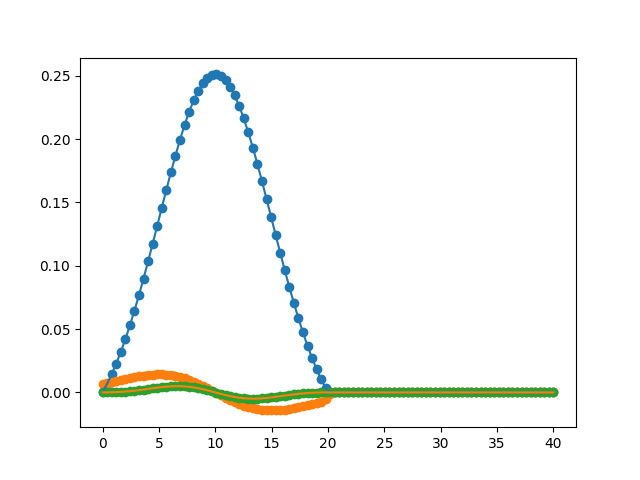

In [7]:
fig, ax = plt.subplots()
ax.scatter(times, waveform_Gaussian,label='')
ax.plot(times, np.real(waveform_general))
ax.scatter(times, waveform_DRAG_1)
ax.plot(times, -np.imag(waveform_general))
ax.scatter(times, waveform_DRAG_2)

# A. Amplified amplitude error (AAE) protocol 

In [9]:
# Simulation wrapper
def simulateAAE(gamma, N_values, A0, lambdas, beta):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta
    H0, H1, H1_dag, H2, H2_dag, H3, H3_dag = Hamiltonian(lambdas, delta, Delta)
    H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
            [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
            [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))]]
    
    pops = []
    for N in N_values:
        psi0 = ket1
        pulse_train = {'clock': 0}
        add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
        counter = 0
        for i in range(N):
            add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
            counter += 1
            add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
            counter += 1
        times = np.linspace(0, pulse_train['clock'], 10000)
        options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
        result = qt.sesolve(H, psi0, times,
                            e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3],
                            args=pulse_train, options=options)
        pops.append(result.expect[2][-1])  # pop of |2⟩
    print(A0, lambdas, beta)
    return np.array(pops)

# Loss function
def lossAAE(gamma, pop_data, N_values, A0, lambdas, beta):
    try:
        sim_data = simulateAAE(gamma, N_values, A0, lambdas, beta)
        print(np.mean((sim_data - pop_data)**2))
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

## A.1 Before correction

(`aaa_uncorrected.npz`)

In [10]:
aae_uncorrected = np.load('./data/amplifying_amplitude_error/aae_uncorrected.npz')
aae_uncorrected_pop2 = aae_uncorrected['pop2']
aae_Nvalues = aae_uncorrected['N']

aae_uncorrected

NpzFile './data/amplifying_amplitude_error/aae_uncorrected.npz' with keys: N, pop2

### A.1.1. Fit using the underlying dynamics

In [ ]:
# === Optimization ===
# This optimization takes around 1 hour to converge
pop_data = aae_uncorrected_pop2
initial_guess = [-0.0007]
bounds = [(-0.005, 0)]

args = ()

resultAAE_uncorrected = minimize(
    lossAAE,
    initial_guess,
    args=(amp_uncorrected, lambdas, beta, pop_data),
    bounds=bounds,
    method="L-BFGS-B"
)

print("Optimal gamma:", resultAAE_uncorrected.x[0])
print("Final loss:", resultAAE_uncorrected.fun)

0.526 0.621 0.753


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.0023500582530501662
0.526 0.621 0.753
0.002350074540508836
0.526 0.621 0.753
0.02074568142533933
0.526 0.621 0.753
0.02074549199925126
0.526 0.621 0.753
0.0009359640950308238
0.526 0.621 0.753
0.0009359733896304982
0.526 0.621 0.753
0.002872885548783329
0.526 0.621 0.753
0.002872839386322253
0.526 0.621 0.753
0.0007107794063746096
0.526 0.621 0.753
0.0007107802885027751
0.526 0.621 0.753
0.0007079826415676897
0.526 0.621 0.753
0.0007079830263126458
0.526 0.621 0.753
0.0007090333292836884
0.526 0.621 0.753
0.0007090324803508194
0.526 0.621 0.753
0.0007079682315444429
0.526 0.621 0.753
0.0007079683949555702
0.526 0.621 0.753
0.0007080391425806791
0.526 0.621 0.753
0.0007080389820453976
0.526 0.621 0.753
0.0007079746268578593
0.526 0.621 0.753
0.0007079743690010179
0.526 0.621 0.753
0.0007079698654160246
0.526 0.621 0.753
0.0007079699686016843
0.526 0.621 0.753
0.0007079687025755524
0.526 0.621 0.753
0.0007079687115309713
0.526 0.621 0.753
0.0007079684060226558
0.526 0.621 0.753
0.00070

In [10]:
# This copies directly the results obtained above to avoid running it again (because it's long)
resultAAE_uncorrected_gamma = -0.0022233774621466112
resultAAE_uncorrected_loss = 0.0007079681903372428

In [11]:
print(aae_Nvalues)
aae_uncorrected_pop2_sim_dynamics = simulateAAE(gamma=resultAAE_uncorrected_gamma, A0=amp_90_12_uncorrected, lambdas=lambdas, beta=0)

[ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40]


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.2512 [0.526 0.621 0.753] 0


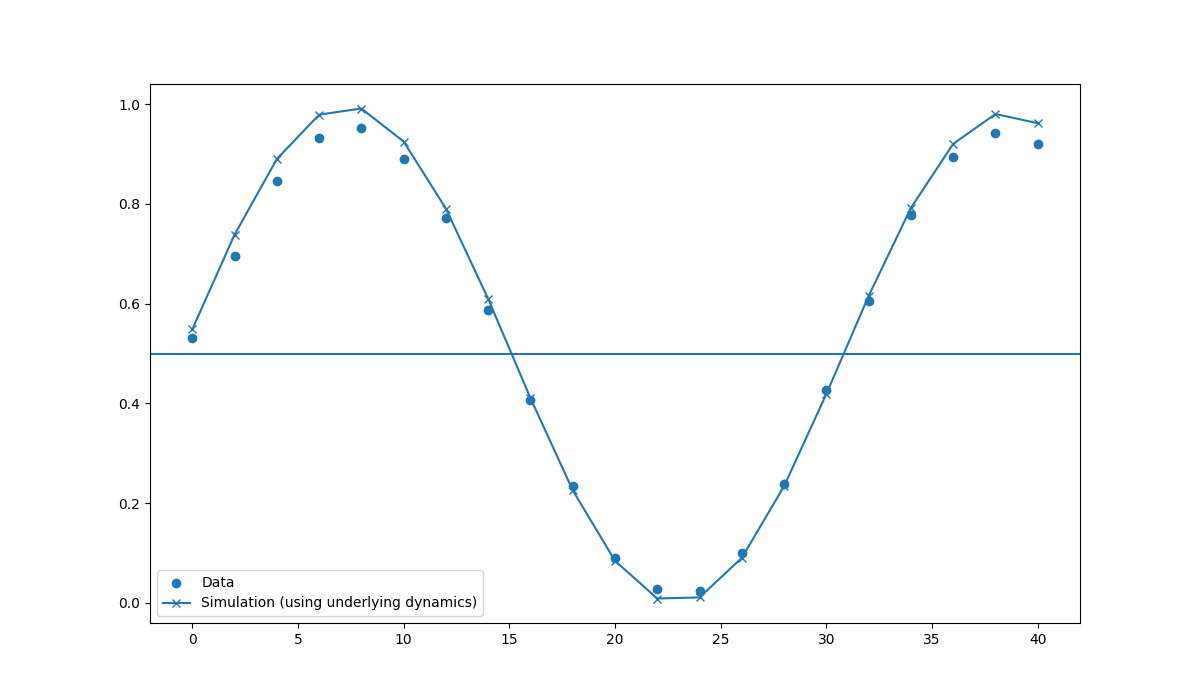

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_uncorrected_pop2, label='Data')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_sim_dynamics, '-x', label='Simulation (using underlying dynamics)')
ax.legend()

### A.1.2. Fit using a simple unitary

In [126]:
def Lx12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 0, 1],
        [0, 1, 0]
    ]))

def Lz12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, -1]
    ]))

def rot_x12(epsilon, Delta):
    return (-1j*((np.pi/2+epsilon)/2)*Lx12()-1j*(Delta/2)*Lz12()).expm()

def rot_z12(phi):
    return (-1j*(phi/2)*Lz12()).expm()

def simple_unitary_simulation(a0, p0):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """
    
    ket0 = qt.basis(3, 0)
    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)

    pops = []
    for N in aae_Nvalues:
        psi0 = ket1
        psi0 = rot_x12(a0, p0)*psi0
        for _ in range(N):
            psi0 = rot_x12(a0, p0)*rot_x12(a0, p0)*psi0
        pop2 = (np.abs(ket2.dag()*psi0))**2
        pops.append(pop2)

    return np.array(pops)

def loss_simple_untiary(params):
    a0, p0 = params
    try:
        sim_data = simple_unitary_simulation(a0, p0)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [14]:
# === Optimization ===
### This optimization is very fast

pop_data = aae_uncorrected_pop2 # Using data
initial_guess = [0.1, 0.25]
bounds = [(0, 0.2), (0, 0.5)]

resultAAE_uncorrected_simple_unitary = minimize(loss_simple_untiary, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAAE_uncorrected_simple_unitary.x[0])
print("Optimal p:", resultAAE_uncorrected_simple_unitary.x[1])
print("Final loss:", resultAAE_uncorrected_simple_unitary.fun)

Optimal a: 0.0628980753923314
Optimal p: 0.3536804717847655
Final loss: 0.00012654881968218645


In [15]:
# === Optimization ===
### This optimization is very fast

pop_data = aae_uncorrected_pop2_sim_dynamics # Using simulation
initial_guess = [0.1, 0.25]
bounds = [(0, 0.2), (0, 0.5)]

resultAAE_uncorrected_simple_unitary = minimize(loss_simple_untiary, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAAE_uncorrected_simple_unitary.x[0])
print("Optimal p:", resultAAE_uncorrected_simple_unitary.x[1])
print("Final loss:", resultAAE_uncorrected_simple_unitary.fun)

Optimal a: 0.09314839908597058
Optimal p: 0.15574199902194533
Final loss: 1.44374072346798e-05


In [16]:
aae_uncorrected_pop2_sim_simple = simple_unitary_simulation(resultAAE_uncorrected_simple_unitary.x[0], resultAAE_uncorrected_simple_unitary.x[1])

aae_uncorrected_pop2_sim_simple

array([0.54534861, 0.734204  , 0.88508463, 0.97397145, 0.98671434,
       0.92128474, 0.78809854, 0.60835797, 0.41067639, 0.22652319,
       0.08521417, 0.00924467, 0.01070845, 0.08937249, 0.23271406,
       0.41791429, 0.61549068, 0.79399057, 0.92499814, 0.98765796,
       0.97199507])

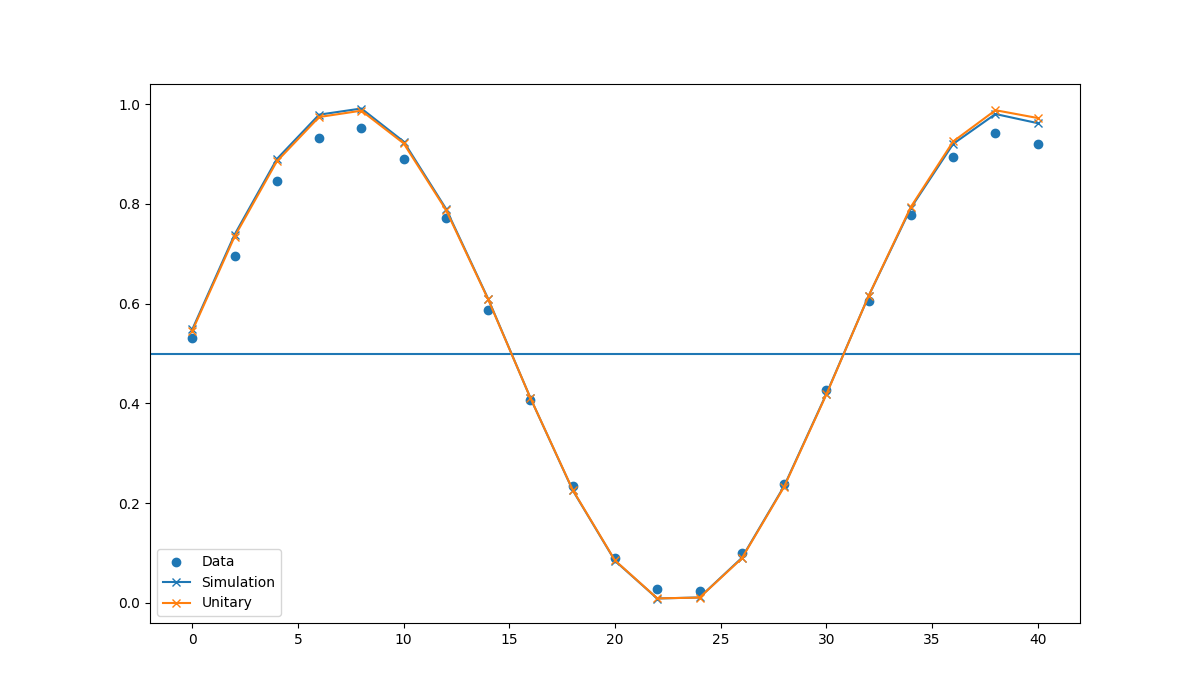

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_uncorrected_pop2, label='Data')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_sim_simple, '-x', label='Unitary')
ax.legend()

### A.1.3. Result using a simple unitary fit

In [18]:
amp_uncorrected_scaled = amp_90_12_uncorrected/(1+2*resultAAE_uncorrected_simple_unitary.x[0]/np.pi)
print(amp_uncorrected_scaled)
aae_uncorrected_pop2_simple_scaled = simulateAAE(gamma=resultAAE_uncorrected_gamma, A0=amp_uncorrected_scaled, lambdas=lambdas, beta=0)

0.23713770725286032
0.23713770725286032 [0.526 0.621 0.753] 0


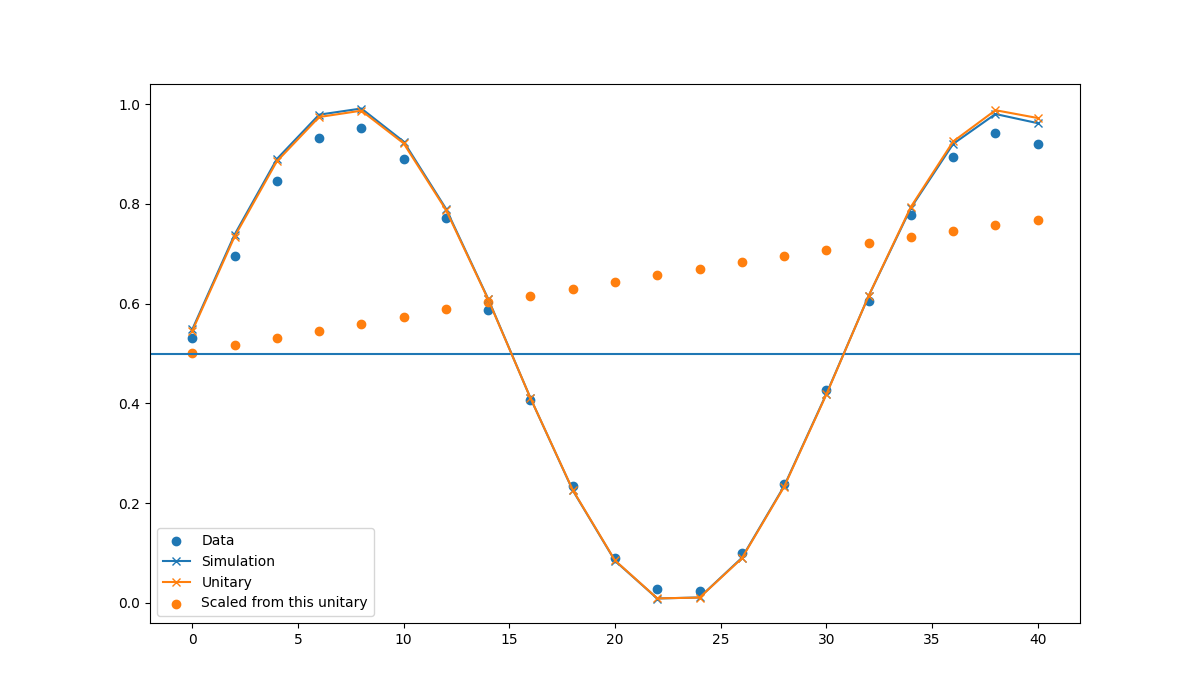

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_uncorrected_pop2, label='Data')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_sim_simple, '-x', label='Unitary')
ax.scatter(aae_Nvalues, aae_uncorrected_pop2_simple_scaled, label='Scaled from this unitary')

ax.legend()

### A.1.4. Fit using a nice untiary

In [20]:
def X_p2epsilon(epsilon):
    return (-1j*(np.pi/2+epsilon)/2*Lx12()).expm()

def Z(delta):
    return (-1j*delta/2*Lz12()).expm()

def nice_untiary(epsilon, delta):
    return Z(delta)*X_p2epsilon(epsilon)*Z(delta)

def nice_untiary_simulation(a0, p0):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """
    
    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)

    pops = []
    for N in aae_Nvalues:
        psi0 = ket1
        psi0 = nice_untiary(a0, p0)*psi0
        for _ in range(N):
            psi0 = nice_untiary(a0, p0)*nice_untiary(a0, p0)*psi0
        pop2 = (np.abs(ket2.dag()*psi0))**2
        pops.append(pop2)
    return np.array(pops)

def loss_nice_unitary(params):
    a0, p0 = params
    try:
        sim_data = nice_untiary_simulation(a0, p0)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [30]:
# === Optimization ===
### This optimization is very fast

pop_data = aae_uncorrected_pop2
initial_guess = [0.1, 0.1]
bounds = [(0, 0.2), (0, 0.2)]

resultAAE_uncorrected_nice_unitary = minimize(loss_nice_unitary, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAAE_uncorrected_nice_unitary.x[0])
print("Optimal p:", resultAAE_uncorrected_nice_unitary.x[1])
print("Final loss:", resultAAE_uncorrected_nice_unitary.fun)

Optimal a: 0.06375886521610019
Optimal p: 0.19943794219112196
Final loss: 0.00018472786763699717


In [31]:
# === Optimization ===
### This optimization is very fast

pop_data = aae_uncorrected_pop2_sim_dynamics
initial_guess = [0.1, 0.1]
bounds = [(0, 0.2), (0, 0.2)]

resultAAE_uncorrected_nice_unitary = minimize(loss_nice_unitary, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAAE_uncorrected_nice_unitary.x[0])
print("Optimal p:", resultAAE_uncorrected_nice_unitary.x[1])
print("Final loss:", resultAAE_uncorrected_nice_unitary.fun)

Optimal a: 0.09260533919612425
Optimal p: 0.0926325429424007
Final loss: 1.5611362707424364e-05


In [32]:
aae_uncorrected_pop2_nice_unitary = nice_untiary_simulation(resultAAE_uncorrected_nice_unitary.x[0], resultAAE_uncorrected_nice_unitary.x[1])

aae_uncorrected_pop2_nice_unitary

array([0.54623652, 0.73537768, 0.88649747, 0.97554556, 0.98835017,
       0.92287348, 0.78953594, 0.60955789, 0.41158237, 0.22711669,
       0.08551811, 0.00932167, 0.01065386, 0.08930265, 0.2327513 ,
       0.4181703 , 0.61605069, 0.79490031, 0.92625568, 0.98921194,
       0.97374974])

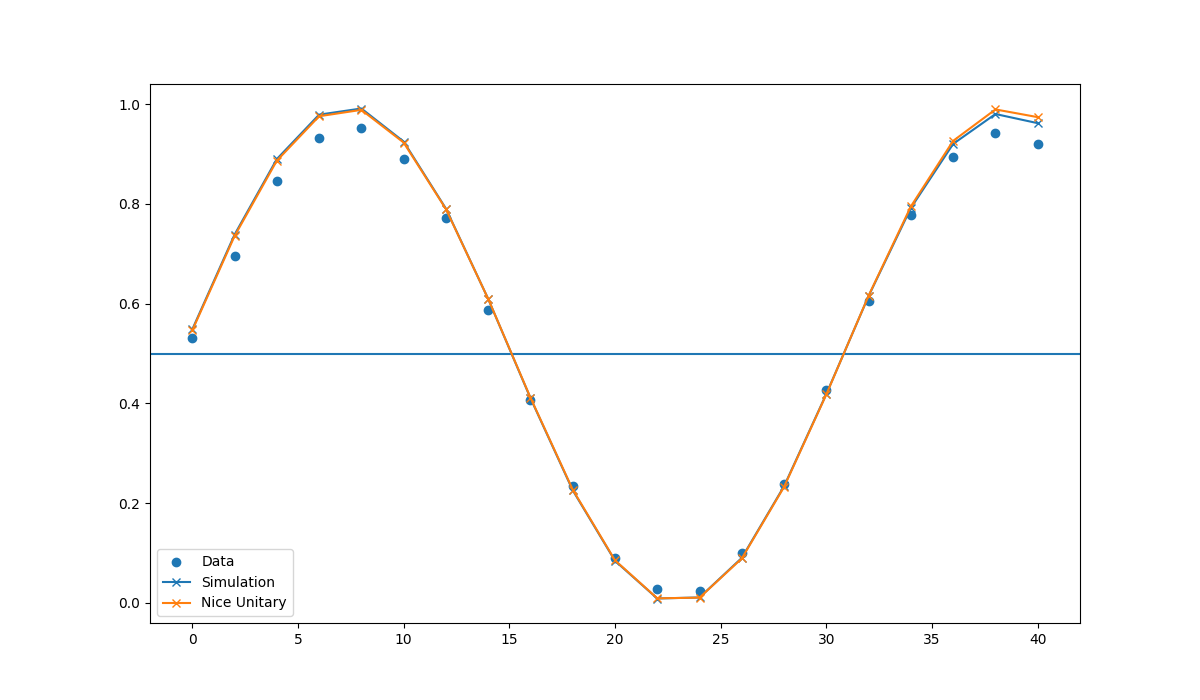

In [33]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_uncorrected_pop2, label='Data')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_nice_unitary, '-x', label='Nice Unitary')
ax.legend()

### A.1.5. Result using a nice unitary

In [34]:
amp_uncorrected_scaled_nice_unitary = amp_90_12_uncorrected/(1+2*resultAAE_uncorrected_nice_unitary.x[0]/np.pi)
print(amp_uncorrected_scaled_nice_unitary)
aae_uncorrected_scaled_pop2_simulation_nice_unitary = simulateAAE(gamma=resultAAE_uncorrected_gamma, A0=amp_uncorrected_scaled_nice_unitary, lambdas=lambdas, beta=0)

0.23721512690429636


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.23721512690429636 [0.526 0.621 0.753] 0


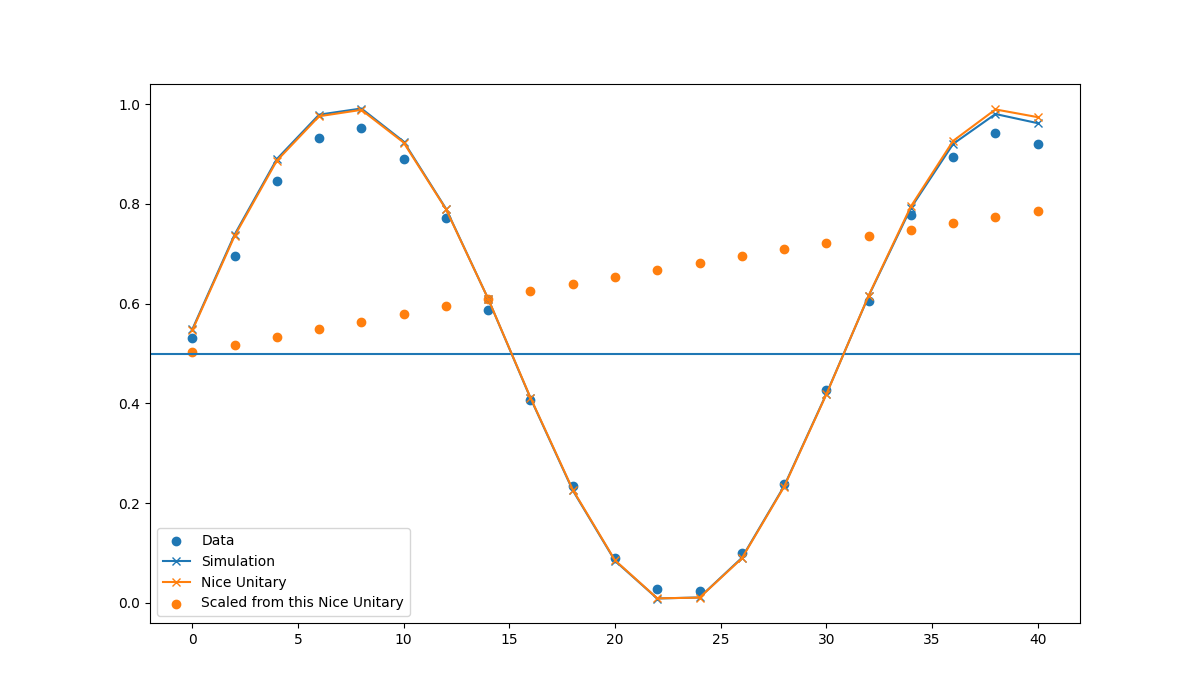

In [35]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_uncorrected_pop2, label='Data')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_uncorrected_pop2_nice_unitary, '-x', label='Nice Unitary')
ax.scatter(aae_Nvalues, aae_uncorrected_scaled_pop2_simulation_nice_unitary, label='Scaled from this Nice Unitary')

ax.legend()

## A.2. After DRAG-Y correction

(`aae_only_dragy`)

In [36]:
aae_dragy = np.load('./data/amplifying_amplitude_error/aae_only_dragy.npz')
aae_dragy_pop2 = aae_dragy['pop2']

aae_dragy

NpzFile './data/amplifying_amplitude_error/aae_only_dragy.npz' with keys: N_values, pop2

### A.2.1 Fit using the underlying dynamics

In [162]:
# === Optimization ===
# This optimization takes around 1 hour to converge
pop_data = aae_dragy_pop2
initial_guess = [-0.0009]
bounds = [(-0.002, 0)]

resultAAE_dragy = minimize(lossAAE, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal gamma:", resultAAE_dragy.x[0])
print("Final loss:", resultAAE_dragy.fun)

c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.00017346235088546152
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.00017346281495232675
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.0005840269389794619
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.0005840138772311898
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.00016861693456149036
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.0001686169661399383
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.0001685737722618315
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.0001685739016693917
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.00016894401029510434
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.00016894406906911292
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.00016857194660743397
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.00016857196443760336
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.000168703181032804
0.2512 [0.526 0.621 0.753] 0.2088552330382085
0.0001687031636039988
0.2512 [0.526 0.621 0.753] 0.2088552330382

In [37]:
resultAAE_dragy_gamma = -0.0010835885986478552
resultAAE_dragy_loss = 0.00016857194660743397

In [ ]:
aae_dragy_pop2_sim_dynamics = simulateAAE(gamma=resultAAE_dragy_gamma, A0=amp_90_12_uncorrected, lambdas=lambdas, beta=0.403/(2*np.pi*0.3071))

0.2512 [0.526 0.621 0.753] 0.2088552330382085


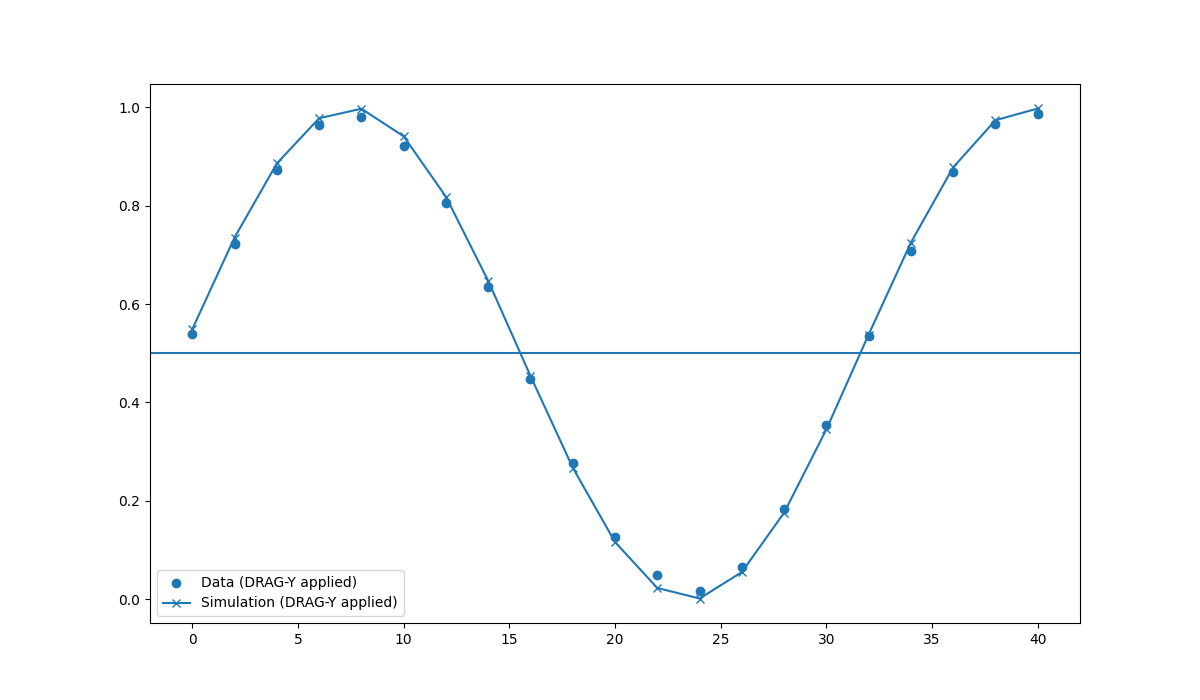

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(aae_Nvalues, aae_dragy_pop2, label='Data (DRAG-Y applied)')
ax.plot(aae_Nvalues, aae_dragy_pop2_sim_dynamics, '-x', label='Simulation (DRAG-Y applied)')
ax.axhline(0.5)
ax.legend()

### A.2.2. Fit using a simple unitary

In [40]:
# === Optimization ===
### This optimization is very fast

pop_data = aae_dragy_pop2
initial_guess = [0.1, 0]
bounds = [(0, 0.2), (0, 0.5)]

resultAAE_dragy_simple_unitary = minimize(loss_simple_untiary, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAAE_dragy_simple_unitary.x[0])
print("Optimal p:", resultAAE_dragy_simple_unitary.x[1])
print("Final loss:", resultAAE_dragy_simple_unitary.fun)

Optimal a: 0.09778185415722274
Optimal p: 9.986819891179098e-12
Final loss: 0.00018323490533079005


In [41]:
aae_dragy_pop2_simple_unitary = simple_unitary_simulation(resultAAE_dragy_simple_unitary.x[0], resultAAE_dragy_simple_unitary.x[1])

aae_dragy_pop2_simple_unitary

array([0.54881305, 0.73483161, 0.88538113, 0.97772256, 0.99790862,
       0.9428904 , 0.82097788, 0.65058476, 0.45744727, 0.27073696,
       0.1186546 , 0.02417078, 0.00155636, 0.05422702, 0.17422737,
       0.34343253, 0.53628568, 0.72365824, 0.87724938, 0.97386066,
       0.99889987])

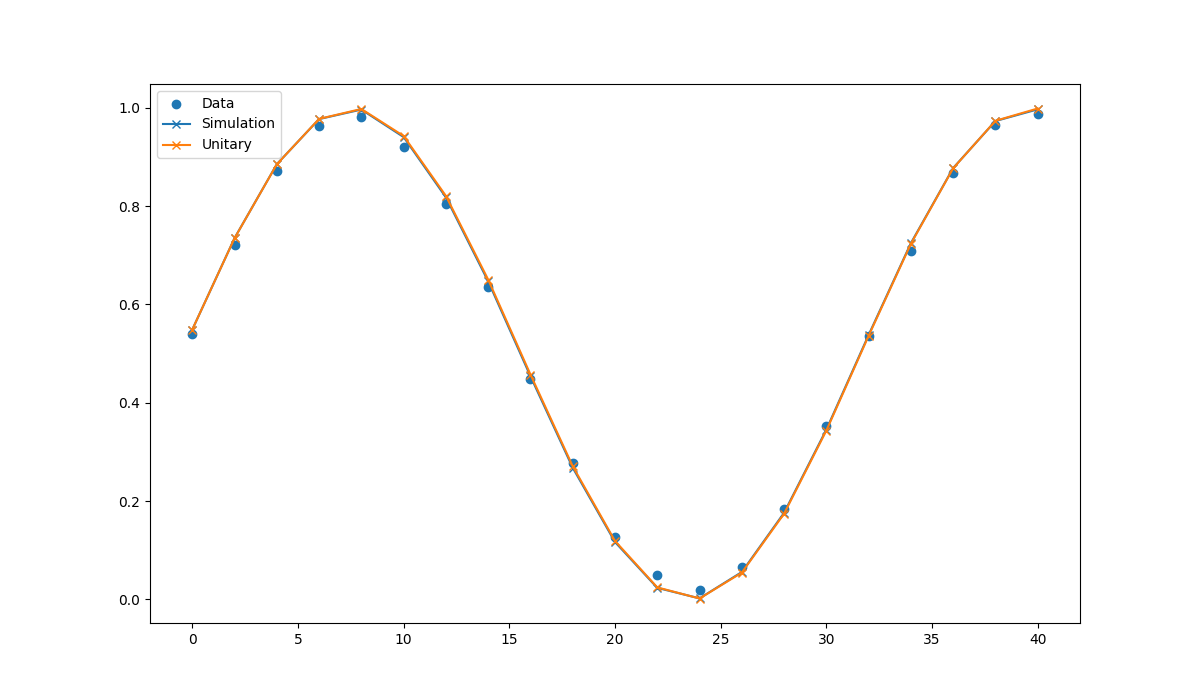

In [43]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(aae_Nvalues, aae_dragy_pop2, label='Data')
ax.plot(aae_Nvalues, aae_dragy_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_dragy_pop2_simple_unitary, '-x', label='Unitary')
ax.legend()

### A.2.3. Result using a simple unitary fit

In [ ]:
amp_dragy_scaled = amp_90_12_uncorrected/(1+2*resultAAE_dragy_simple_unitary.x[0]/np.pi)
print(amp_dragy_scaled)
aae_dragy_scaled_simple_pop2_simulation = simulateAAE(gamma=resultAAE_dragy_gamma, A0=amp_dragy_scaled, lambdas=lambdas, beta=0.403/(2*np.pi*0.3071))

0.23647920235042363


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.23647920235042363 [0.526 0.621 0.753] 0.2088552330382085


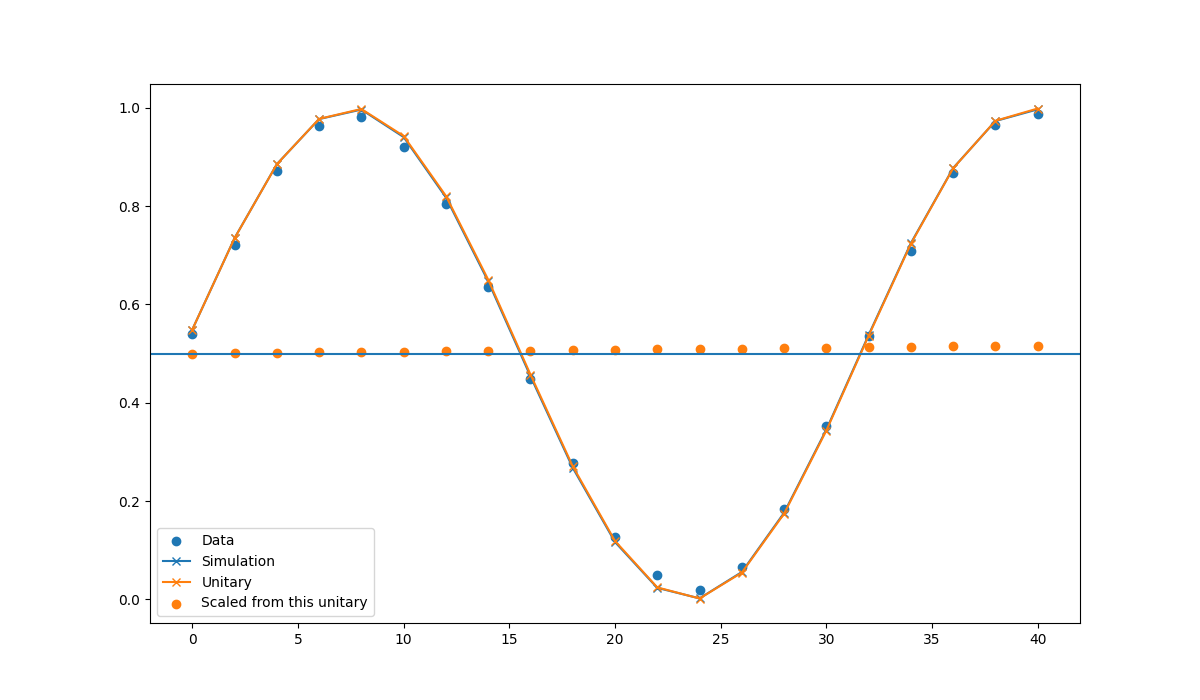

In [46]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(aae_Nvalues, aae_dragy_pop2, label='Data')
ax.plot(aae_Nvalues, aae_dragy_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_dragy_pop2_simple_unitary, '-x', label='Unitary')
ax.scatter(aae_Nvalues, aae_dragy_scaled_simple_pop2_simulation, label='Scaled from this unitary')
ax.axhline(0.5)
ax.legend()

### A.2.4. Fit using a nice unitary

In [ ]:
# === Optimization ===
### This optimization is very fast

pop_data = aae_dragy_pop2
initial_guess = [0.1, 0]
bounds = [(0, 0.2), (0, 0.2)]

resultAAE_dragy_nice_unitary = minimize(loss_nice_unitary, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAAE_dragy_nice_unitary.x[0])
print("Optimal p:", resultAAE_dragy_nice_unitary.x[1])
print("Final loss:", resultAAE_dragy_nice_unitary.fun)

Simulation error: nice_untiary() missing 1 required positional argument: 'sign'
Simulation error: nice_untiary() missing 1 required positional argument: 'sign'
Simulation error: nice_untiary() missing 1 required positional argument: 'sign'
Optimal a: 0.1
Optimal p: 0.0
Final loss: 1000000.0


In [48]:
aae_dragy_pop2_nice_unitary = nice_untiary_simulation(resultAAE_dragy_nice_unitary.x[0], resultAAE_dragy_nice_unitary.x[1])

aae_dragy_pop2_nice_unitary

array([0.54881305, 0.73483161, 0.88538113, 0.97772256, 0.99790862,
       0.9428904 , 0.82097788, 0.65058476, 0.45744727, 0.27073696,
       0.1186546 , 0.02417078, 0.00155636, 0.05422702, 0.17422737,
       0.34343253, 0.53628568, 0.72365824, 0.87724938, 0.97386066,
       0.99889987])

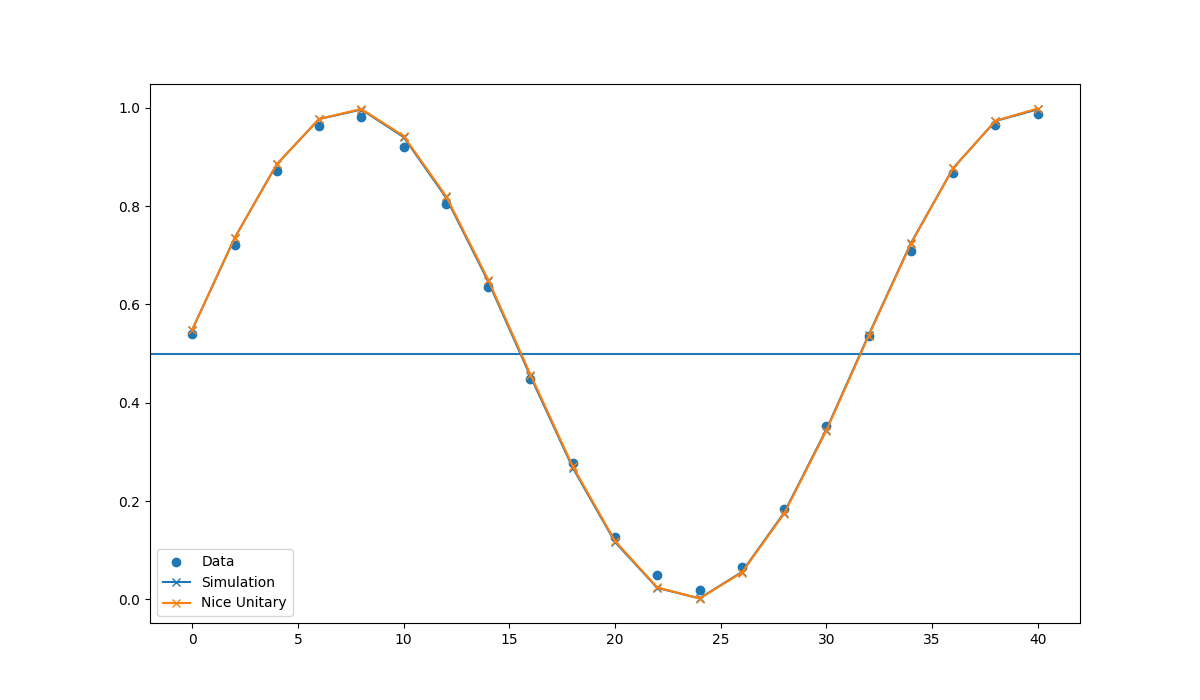

In [49]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_dragy_pop2, label='Data')
ax.plot(aae_Nvalues, aae_dragy_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_dragy_pop2_nice_unitary, '-x', label='Nice Unitary')
ax.legend()

### A.2.5. Result using a nice unitary

In [54]:
amp_dragy_scaled_nice_unitary = amp_90_12_uncorrected/(1+2*resultAAE_dragy_nice_unitary.x[0]/np.pi)
print(amp_dragy_scaled_nice_unitary)
aae_dragy_scaled_pop2_simulation_nice_unitary = simulateAAE(gamma=-0.0006268518233238079, A0=amp_dragy_scaled_nice_unitary, lambdas=lambdas, beta=0.403/(2*np.pi*0.3071))

0.23647920235042363
0.23647920235042363 [0.526 0.621 0.753] 0.2088552330382085


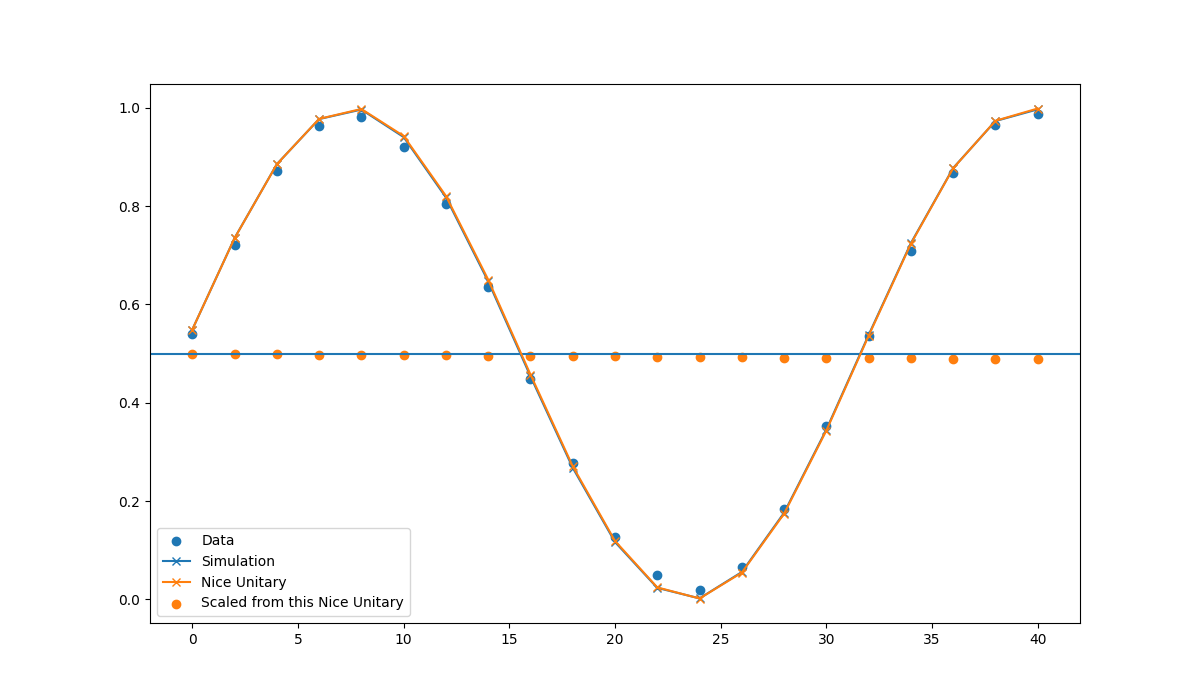

In [51]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_dragy_pop2, label='Data')
ax.plot(aae_Nvalues, aae_dragy_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_dragy_pop2_nice_unitary, '-x', label='Nice Unitary')
ax.scatter(aae_Nvalues, aae_dragy_scaled_pop2_simulation_nice_unitary, label='Scaled from this Nice Unitary')

ax.legend()

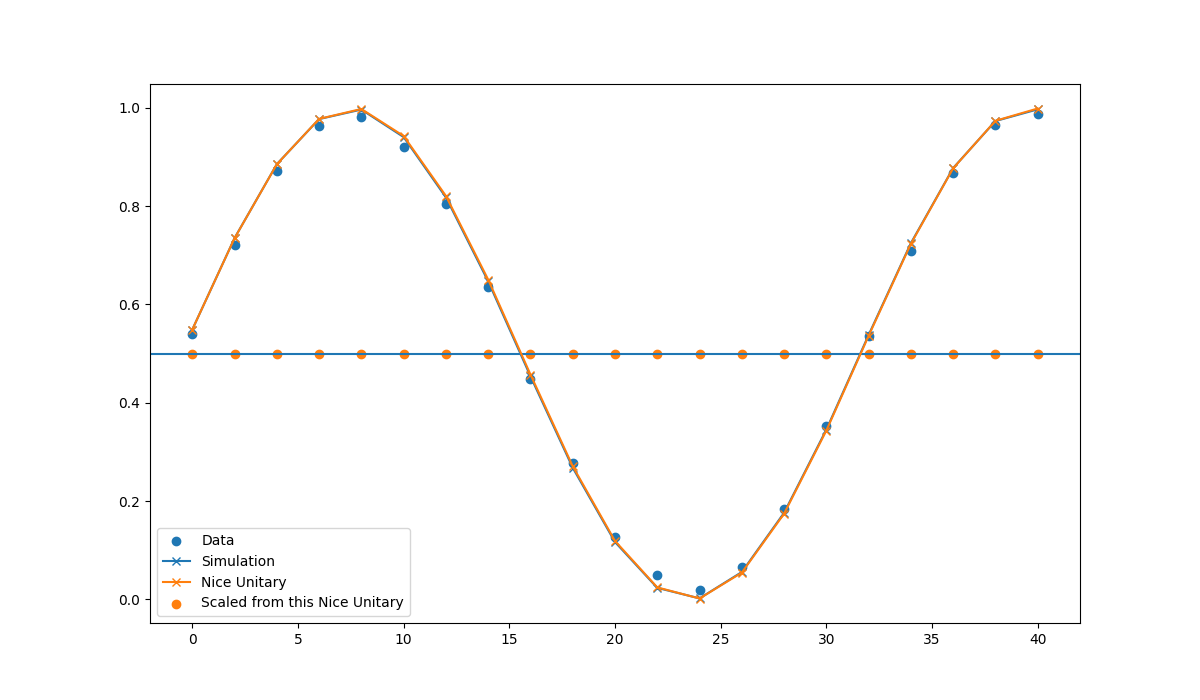

In [55]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.axhline(0.5) 
ax.scatter(aae_Nvalues, aae_dragy_pop2, label='Data')
ax.plot(aae_Nvalues, aae_dragy_pop2_sim_dynamics, '-x', label='Simulation')
ax.plot(aae_Nvalues, aae_dragy_pop2_nice_unitary, '-x', label='Nice Unitary')
ax.scatter(aae_Nvalues, aae_dragy_scaled_pop2_simulation_nice_unitary, label='Scaled from this Nice Unitary')

ax.legend()

# B. Amplified phase error (APE) protocol 

## B.1. Before correction

(`ape_data.npz`)

In [56]:
ape_uncorrected = np.load('./data/amplifying_phase_error/ape_data.npz')
ape_angle_swept = ape_uncorrected['angle_swept']
ape_uncorrected_populations = ape_uncorrected['pe_pops']

ape_uncorrected

NpzFile './data/amplifying_phase_error/ape_data.npz' with keys: angle_swept, pe_pops

In [57]:
# Simulation wrapper
def simulateAPE(gamma, A0=amp_90_12_uncorrected, lambdas=lambdas, beta=beta0):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta

    H0, H1, H1_dag, H2, H2_dag, H3, H3_dag= Hamiltonian(lambdas, delta, Delta)
    H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
            [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
            [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))]]
    
    pops = []
    rep_range = [1, 3, 5, 7, 9, 11, 13, 15]
    for rep in rep_range:
        pops_versus_angles = []
        for phi in ape_angle_swept:
            A0_phi = A0*np.exp(1j*phi)
            psi0 = ket1
            pulse_train = {'clock': 0}
            add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
            counter = 0
            for r in range(rep):
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
                counter += 1
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=-A0, beta=beta)
                counter += 1
            add_pulse(pulse_train, 'map_phase_to_pop', start=pulse_train['clock'], tg=20, sigma=5, A=-A0_phi, beta=beta)
            times = np.linspace(0, pulse_train['clock'], 5000)
            options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
            result = qt.sesolve(H, psi0, times,
                                e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3],
                                args=pulse_train, options=options)
            pops_versus_angles.append(result.expect[1][-1])  # pop of |2⟩
        pops.append(pops_versus_angles)
    print(A0, lambdas, beta)
    return np.array(pops)

# Loss function
def lossAPE(gamma):
    try:
        sim_data = simulateAPE(gamma)[3] # getting result from AAE
        print(np.mean((sim_data - ape_pops[3][:, 2])**2))
        return np.mean((sim_data - ape_pops[3][:, 2])**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

### B.1.1. Fit using the underlying dynamics

In [40]:
# === Optimization ===
# This optimization takes around half an hour to converge
ape_pops = ape_uncorrected_populations
initial_guess = [-0.0007737085303671151]
bounds = [(-0.005, 0)] # within 3 MHz of charge dispersion

resultAPE = minimize(lossAPE, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal gamma:", resultAPE.x[0])
print("Final loss:", resultAPE.fun)

0.526 0.621 0.753


c:\Users\ngdnh\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.00038937360095735044
0.526 0.621 0.753
0.00038934444659943296
0.526 0.621 0.753
0.004257784819846783
0.526 0.621 0.753
0.004257649673728509
0.526 0.621 0.753
0.00018361268905601276
0.526 0.621 0.753
0.00018361255687832524
0.526 0.621 0.753
0.00018361245305334526
0.526 0.621 0.753
0.00018361258915575165
0.526 0.621 0.753
0.00018361152803614557
0.526 0.621 0.753
0.00018361146902937852
Optimal gamma: -0.0006268518233238079
Final loss: 0.00018361152803614557


In [58]:
resultAPE_uncorrected_gamma = -0.0006268518233238079
resultAPE_uncorrected_loss = 0.00018361152803614557

In [59]:
ape_uncorrected_pop2_simulation = simulateAPE(gamma=resultAPE_uncorrected_gamma, A0=amp_90_12_uncorrected, lambdas=lambdas, beta=0)

0.2512 [0.526 0.621 0.753] 0


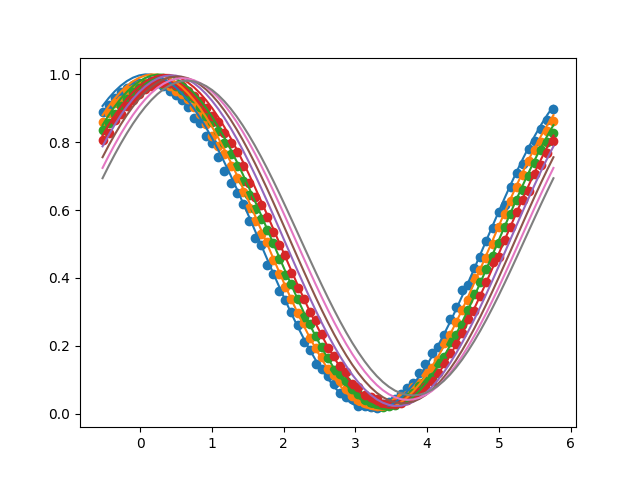

In [60]:
fig, ax = plt.subplots()

ax.scatter(ape_angle_swept, ape_uncorrected_populations[0][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[1][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[2][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[3][:, 0])

ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[0])
ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[1])
ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[2])
ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[3])
ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[4])
ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[5])
ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[6])
ax.plot(ape_angle_swept, ape_uncorrected_pop2_simulation[7])

### B.1.2. Fit using a simple unitary

In [61]:
def ape_plus(a, p):
    return (-1j*((np.pi/2+a)/2)*Lx12()-1j*(p/2)*Lz12()).expm() 

def ape_minus(a, p):
    return (-1j*((-np.pi/2-a)/2)*Lx12()-1j*(p/2)*Lz12()).expm() 

def APE_simple_unitary_simulation(a0, p0):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """

    ket1 = qt.basis(3, 1)
    pops = []
    rep_range = [1, 3, 5, 7, 9, 11, 13, 15]
    for rep in rep_range:
        pops_versus_angles = []
        for phi in ape_angle_swept:
            psi0 = -1j*ket1
            psi0 = rot_x12(a0, p0)*psi0 
            for r in range(rep):
                psi0 = ape_minus(a0, p0)*ape_plus(a0, p0)*psi0
            psi0 = rot_z12(phi)*ape_minus(a0, p0)*rot_z12(-phi)*psi0
            pop2 = (np.abs(ket1.dag()*psi0))**2
            pops_versus_angles.append(pop2)  # pop of |2⟩
        pops.append(pops_versus_angles)
    return np.array(pops)

def APE_simple_unitary_loss(params):
    a0, p0 = params
    try:
        sim_data = APE_simple_unitary_simulation(a0, p0)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [ ]:
# === Optimization ===
### This optimization is very fast

pop_data = ape_uncorrected_pop2_simulation
initial_guess = [0.01, 0.05]
bounds = [(0, 0.2), (-0.5, 0.5)]

resultAPE_uncorrected_simple_unitary = minimize(APE_simple_unitary_loss, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAPE_uncorrected_simple_unitary.x[0])
print("Optimal p:", resultAPE_uncorrected_simple_unitary.x[1])
print("Final loss:", resultAPE_uncorrected_simple_unitary.fun)

Optimal a: 0.09726231217991348
Optimal p: 0.04194329252355048
Final loss: 2.251402220570004e-10


In [69]:
aae_uncorrected_pop2_simple_unitary = APE_simple_unitary_simulation(resultAPE_uncorrected_simple_unitary.x[0], resultAPE_uncorrected_simple_unitary.x[1])

aae_uncorrected_pop2_simple_unitary

array([[0.90678561, 0.92986141, 0.94987486, 0.96668177, 0.98016103,
        0.99021554, 0.99677285, 0.99978571, 0.99923242, 0.99511696,
        0.98746899, 0.9763436 , 0.96182096, 0.9440057 , 0.92302618,
        0.89903357, 0.87220072, 0.84272097, 0.81080672, 0.77668791,
        0.74061037, 0.70283405, 0.66363111, 0.62328402, 0.58208348,
        0.54032634, 0.49831347, 0.45634755, 0.41473097, 0.37376356,
        0.33374051, 0.29495017, 0.25767203, 0.22217469, 0.18871389,
        0.15753073, 0.12884989, 0.102878  , 0.0798022 , 0.05978875,
        0.04298184, 0.02950258, 0.01944807, 0.01289076, 0.0098779 ,
        0.01043119, 0.01454665, 0.02219462, 0.03332001, 0.04784265,
        0.06565791, 0.08663743, 0.11063004, 0.13746289, 0.16694264,
        0.19885689, 0.2329757 , 0.26905324, 0.30682956, 0.3460325 ,
        0.38637959, 0.42758013, 0.46933727, 0.51135014, 0.55331606,
        0.59493264, 0.63590005, 0.6759231 , 0.71471344, 0.75199158,
        0.78748892, 0.82094972, 0.85213288, 0.88

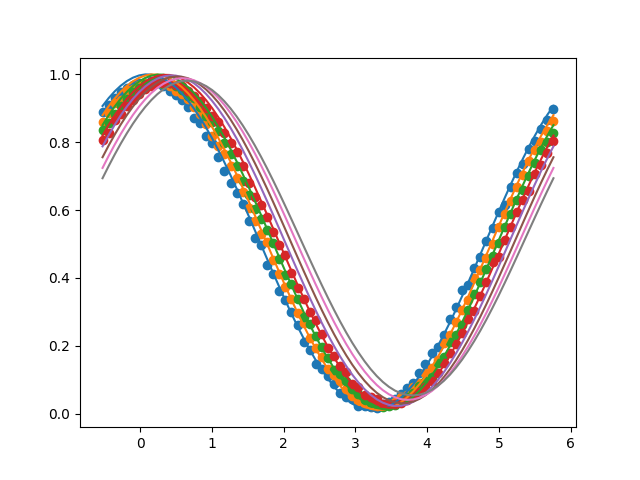

In [71]:
fig, ax = plt.subplots()

ax.scatter(ape_angle_swept, ape_uncorrected_populations[0][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[1][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[2][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[3][:, 0])

ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[0])
ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[1])
ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[2])
ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[3])
ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[4])
ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[5])
ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[6])
ax.plot(ape_angle_swept, aae_uncorrected_pop2_simple_unitary[7])

### B.1.3. Fit using a nice unitary

In [73]:
def X_p2epsilon_plus(epsilon):
    return (-1j*(np.pi/2+epsilon)/2*Lx12()).expm()

def X_p2epsilon_minus(epsilon):
    return (-1j*(-np.pi/2-epsilon)/2*Lx12()).expm()

def Z(delta):
    return (-1j*delta/2*Lz12()).expm()

def nice_untiary(epsilon, delta, sign):
    if sign == 'plus':
        return Z(delta)*X_p2epsilon_plus(epsilon)*Z(delta)
    elif sign == 'minus':
        return Z(delta)*X_p2epsilon_minus(epsilon)*Z(delta)
    else:
        print('Error')
        return 0

def APE_nice_unitary_simulation(a0, p0):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """

    ket1 = qt.basis(3, 1)
    pops = []
    rep_range = [1, 3, 5, 7, 9, 11, 13, 15]
    for rep in rep_range:
        pops_versus_angles = []
        for phi in ape_angle_swept:
            psi0 = -1j*ket1
            psi0 = nice_untiary(a0, p0, 'plus')*psi0 
            for r in range(rep):
                psi0 = nice_untiary(a0, p0, 'minus')*nice_untiary(a0, p0, 'plus')*psi0
            psi0 = Z(phi)*nice_untiary(a0, p0, 'minus')*Z(-phi)*psi0
            pop2 = (np.abs(ket1.dag()*psi0))**2
            pops_versus_angles.append(pop2)  # pop of |1⟩
        pops.append(pops_versus_angles)
    return np.array(pops)

def lost_APE_nice_unitary(params):
    a0, p0 = params
    try:
        sim_data = APE_nice_unitary_simulation(a0, p0)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [74]:
# === Optimization ===
### This optimization is very fast

pop_data = ape_uncorrected_pop2_simulation
initial_guess = [0.01, 0.03]
bounds = [(0, 0.2), (-0.5, 0.5)]

resultAPE_uncorrected_nice_unitary = minimize(lost_APE_nice_unitary, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultAPE_uncorrected_nice_unitary.x[0])
print("Optimal p:", resultAPE_uncorrected_nice_unitary.x[1])
print("Final loss:", resultAPE_uncorrected_nice_unitary.fun)

Optimal a: 0.09709569535887265
Optimal p: 0.02771676618942422
Final loss: 2.2472889409128724e-10


In [75]:
aae_uncorrected_pop2_nice_unitary = APE_nice_unitary_simulation(resultAPE_uncorrected_nice_unitary.x[0], resultAPE_uncorrected_nice_unitary.x[1])

aae_uncorrected_pop2_nice_unitary

array([[0.90678559, 0.92986139, 0.94987484, 0.96668174, 0.98016101,
        0.99021553, 0.99677284, 0.99978571, 0.99923243, 0.99511698,
        0.98746902, 0.97634365, 0.96182103, 0.94400579, 0.92302629,
        0.8990337 , 0.87220087, 0.84272115, 0.81080693, 0.77668815,
        0.74061064, 0.70283434, 0.66363143, 0.62328437, 0.58208385,
        0.54032674, 0.49831389, 0.456348  , 0.41473144, 0.37376405,
        0.33374102, 0.2949507 , 0.25767258, 0.22217525, 0.18871447,
        0.15753132, 0.12885049, 0.10287861, 0.07980281, 0.05978936,
        0.04298246, 0.02950319, 0.01944867, 0.01289136, 0.00987849,
        0.01043177, 0.01454722, 0.02219518, 0.03332055, 0.04784317,
        0.06565841, 0.08663791, 0.1106305 , 0.13746332, 0.16694305,
        0.19885727, 0.23297605, 0.26905356, 0.30682986, 0.34603277,
        0.38637983, 0.42758034, 0.46933746, 0.51135031, 0.5533162 ,
        0.59493276, 0.63590015, 0.67592318, 0.7147135 , 0.75199162,
        0.78748895, 0.82094973, 0.85213288, 0.88

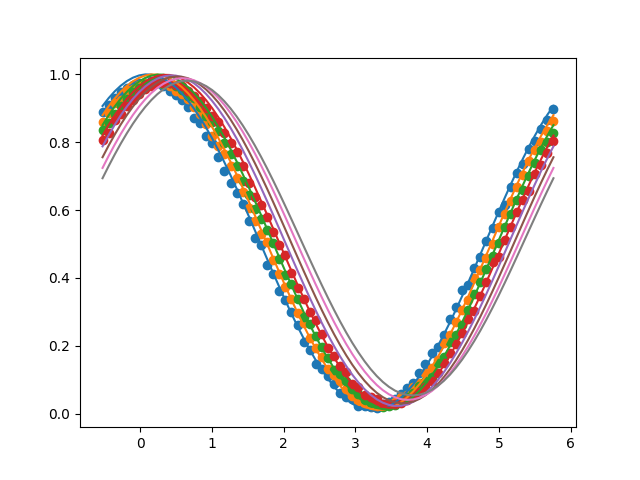

In [77]:
fig, ax = plt.subplots()

ax.scatter(ape_angle_swept, ape_uncorrected_populations[0][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[1][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[2][:, 0])
ax.scatter(ape_angle_swept, ape_uncorrected_populations[3][:, 0])

for i in range(aae_uncorrected_pop2_nice_unitary.shape[0]):
    ax.plot(ape_angle_swept, aae_uncorrected_pop2_nice_unitary[i])

# C. DRAG+APE = DRAPE

In [78]:
drape_sweep = np.load('./data/drag_and_ape/drag_ape_data.npz')

drape_sweep_beta = drape_sweep['beta_swept']
drape_sweep_beta_normalized = drape_sweep_beta/(-2*np.pi*0.3071)
drape_sweep_pops = drape_sweep['drape_pops']

drape_sweep

NpzFile './data/drag_and_ape/drag_ape_data.npz' with keys: beta_swept, drape_pops, y_fit_pops

### C.1.1. Fit using the underlying unitary dynamics

In [79]:
# Simulation wrapper
def simulateDRAPE(gamma, betas=drape_sweep_beta, A0=amp_90_12_uncorrected, lambdas=lambdas):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta

    H0, H1, H1_dag, H2, H2_dag, H3, H3_dag= Hamiltonian(lambdas, delta, Delta)
    H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
            [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
            [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))]]
    
    pops = []
    rep_range = [1, 3, 5, 7, 9, 11]
    for rep in rep_range:
        pops_versus_betas = []
        for beta in betas:
            phi=np.pi/2
            A0_phi = A0*np.exp(1j*phi) # DRAPE protocol, fixed at pi/2
            psi0 = ket1
            pulse_train = {'clock': 0}
            add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
            counter = 0
            for r in range(rep):
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
                counter += 1
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=-A0, beta=beta)
                counter += 1
            add_pulse(pulse_train, 'map_phase_to_pop', start=pulse_train['clock'], tg=20, sigma=5, A=-A0_phi, beta=beta)
            times = np.linspace(0, pulse_train['clock'], 10000)
            options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
            result = qt.sesolve(H, psi0, times,
                                e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3],
                                args=pulse_train, options=options)
            pops_versus_betas.append(result.expect[2][-1])  # pop of |2⟩
            print(A0, lambdas, beta)
            print(np.array(pops_versus_betas).shape)
        pops.append(pops_versus_betas)
    return np.array(pops)

In [148]:
resultDRAPE_sweepbeta_gamma = -0.00038
amp_90_12_scaled = 0.23634684697522249

In [149]:
drape_sweep_pops_simulation = simulateDRAPE(resultDRAPE_sweepbeta_gamma, betas=drape_sweep_beta_normalized, A0=amp_90_12_scaled, lambdas=lambdas)

0.23634684697522249 [0.526 0.621 0.753] 0.5182511986059765
(1,)
0.23634684697522249 [0.526 0.621 0.753] 0.5097899545471033
(2,)
0.23634684697522249 [0.526 0.621 0.753] 0.5013287104882302
(3,)
0.23634684697522249 [0.526 0.621 0.753] 0.49286746642935714
(4,)
0.23634684697522249 [0.526 0.621 0.753] 0.4844062223704841
(5,)
0.23634684697522249 [0.526 0.621 0.753] 0.475944978311611
(6,)
0.23634684697522249 [0.526 0.621 0.753] 0.46748373425273787
(7,)
0.23634684697522249 [0.526 0.621 0.753] 0.4590224901938648
(8,)
0.23634684697522249 [0.526 0.621 0.753] 0.4505612461349917
(9,)
0.23634684697522249 [0.526 0.621 0.753] 0.44210000207611866
(10,)
0.23634684697522249 [0.526 0.621 0.753] 0.4336387580172456
(11,)
0.23634684697522249 [0.526 0.621 0.753] 0.42517751395837244
(12,)
0.23634684697522249 [0.526 0.621 0.753] 0.4167162698994994
(13,)
0.23634684697522249 [0.526 0.621 0.753] 0.40825502584062634
(14,)
0.23634684697522249 [0.526 0.621 0.753] 0.3997937817817532
(15,)
0.23634684697522249 [0.526 0.6

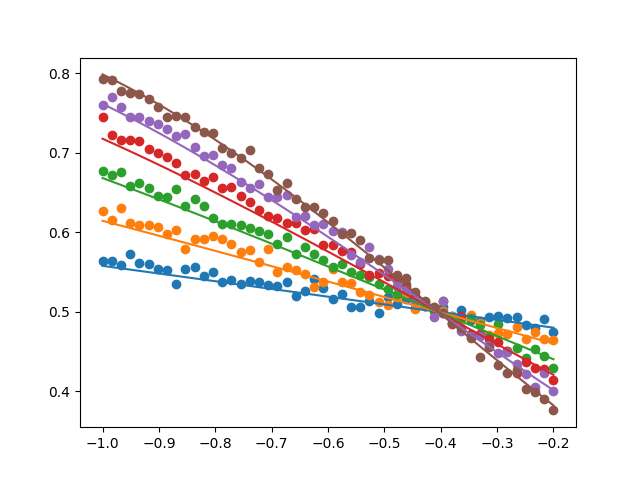

In [150]:
fig, ax = plt.subplots()

for i in range(drape_sweep_pops.shape[0]):
    ax.scatter(drape_sweep_beta, drape_sweep_pops[i][:, 2])
    ax.plot(drape_sweep_beta, drape_sweep_pops_simulation[i])

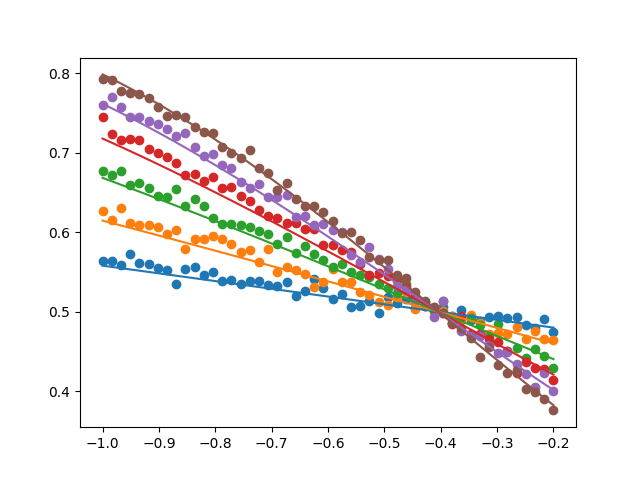

In [130]:
fig, ax = plt.subplots()

for i in range(drape_sweep_pops.shape[0]):
    ax.scatter(drape_sweep_beta, drape_sweep_pops[i][:, 2])
    ax.plot(drape_sweep_beta, drape_sweep_pops_simulation[i])

### C.1.2. Fit using a simple unitary

In [151]:
def ape_plus(a, p):
    return (-1j*((np.pi/2+a)/2)*Lx12()-1j*(p/2)*Lz12()).expm() 

def ape_minus(a, p):
    return (-1j*((-np.pi/2-a)/2)*Lx12()-1j*(p/2)*Lz12()).expm() 

def DRAPE_simple_unitary_simulation(a0, prop_cte):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """

    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)
    pops = []
    rep_range = [1, 3, 5, 7, 9, 11]
    for rep in rep_range:
        pops_versus_p0 = []
        for p0 in drape_sweep_beta:
            p0 = prop_cte*(p0+0.4045)
            psi0 = -1j*ket1
            psi0 = rot_x12(a0, p0)*psi0 
            for r in range(rep):
                psi0 = ape_minus(a0, p0)*ape_plus(a0, p0)*psi0
            psi0 = rot_z12(np.pi/2)*ape_minus(a0, p0)*rot_z12(-np.pi/2)*psi0
            pop2 = (np.abs(ket2.dag()*psi0))**2
            pops_versus_p0.append(pop2)  # pop of |2⟩
        pops.append(pops_versus_p0)
    return np.array(pops)

def DRAPE_simple_unitary_loss(params):
    a0, cte = params
    try:
        sim_data = DRAPE_simple_unitary_simulation(a0, cte)
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [ ]:
# === Optimization ===
### This optimization is very fast

pop_data = drape_sweep_pops[:, :, 2]
initial_guess = [0.1, 0.1]
bounds = [(0.0, 0.2), (0, 0.2)]

resultDRAPE_uncorrected_simple_unitary = minimize(DRAPE_simple_unitary_loss, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultDRAPE_uncorrected_simple_unitary.x[0])
print("Optimal cte:", resultDRAPE_uncorrected_simple_unitary.x[1])
print("Final loss:", resultDRAPE_uncorrected_simple_unitary.fun)

In [152]:
# === Optimization ===
### This optimization is very fast

pop_data = drape_sweep_pops_simulation
initial_guess = [0.1, 0.1]
bounds = [(0.0, 0.2), (0, 0.2)]

resultDRAPE_uncorrected_simple_unitary = minimize(DRAPE_simple_unitary_loss, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultDRAPE_uncorrected_simple_unitary.x[0])
print("Optimal cte:", resultDRAPE_uncorrected_simple_unitary.x[1])
print("Final loss:", resultDRAPE_uncorrected_simple_unitary.fun)

Optimal a: 0.0
Optimal cte: 0.07663797934914539
Final loss: 6.6809555043523236e-09


In [153]:
DRAPE_simulation_simple_unitary = DRAPE_simple_unitary_simulation(resultDRAPE_uncorrected_simple_unitary.x[0], resultDRAPE_uncorrected_simple_unitary.x[1])

DRAPE_simulation_simple_unitary

array([[0.55793679, 0.55635736, 0.55477717, 0.55319626, 0.55161465,
        0.55003234, 0.54844938, 0.54686577, 0.54528153, 0.5436967 ,
        0.54211128, 0.54052531, 0.5389388 , 0.53735176, 0.53576424,
        0.53417623, 0.53258778, 0.53099889, 0.52940958, 0.52781989,
        0.52622983, 0.52463941, 0.52304867, 0.52145763, 0.51986629,
        0.5182747 , 0.51668286, 0.51509079, 0.51349853, 0.51190609,
        0.51031349, 0.50872075, 0.50712789, 0.50553494, 0.50394192,
        0.50234884, 0.50075574, 0.49916262, 0.49756951, 0.49597644,
        0.49438342, 0.49279047, 0.49119762, 0.48960489, 0.4880123 ,
        0.48641986, 0.48482761, 0.48323556, 0.48164373, 0.48005215],
       [0.61451956, 0.61146862, 0.60841033, 0.60534487, 0.60227246,
        0.5991933 , 0.59610758, 0.59301552, 0.58991731, 0.58681317,
        0.58370328, 0.58058787, 0.57746713, 0.57434127, 0.5712105 ,
        0.56807502, 0.56493504, 0.56179077, 0.55864241, 0.55549017,
        0.55233427, 0.5491749 , 0.54601228, 0.5

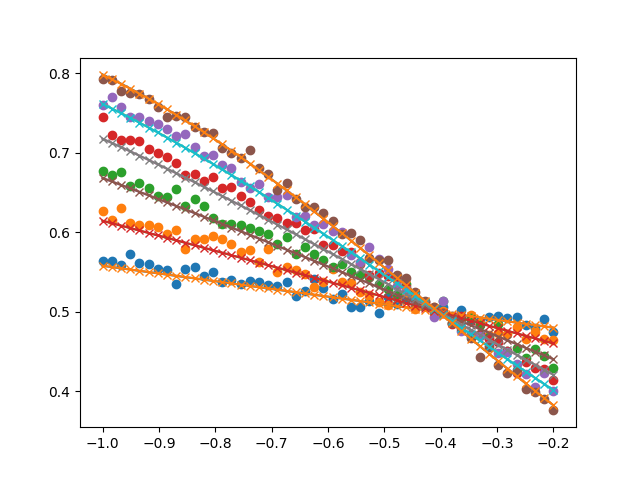

In [154]:
fig, ax = plt.subplots()

for i in range(drape_sweep_pops.shape[0]):
    ax.scatter(drape_sweep_beta, drape_sweep_pops[i][:, 2])
    ax.plot(drape_sweep_beta, drape_sweep_pops_simulation[i])
    ax.plot(drape_sweep_beta, DRAPE_simulation_simple_unitary[i], '-x')

### C.1.3. Fit using a nice untiary

In [156]:
def X_p2epsilon_plus(epsilon):
    return (-1j*(np.pi/2+epsilon)/2*Lx12()).expm()

def X_p2epsilon_minus(epsilon):
    return (-1j*(-np.pi/2-epsilon)/2*Lx12()).expm()

def Z(delta):
    return (-1j*delta/2*Lz12()).expm()

def nice_untiary(epsilon, delta, sign):
    if sign == 'plus':
        return Z(delta)*X_p2epsilon_plus(epsilon)*Z(delta)
    elif sign == 'minus':
        return Z(delta)*X_p2epsilon_minus(epsilon)*Z(delta)
    else:
        print('Error')
        return 0

def DRAPE_nice_unitary_simulation(a0, prop_cte):
    """ 
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """

    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)
    pops = []
    rep_range = [1, 3, 5, 7, 9, 11]
    for rep in rep_range:
        pops_versus_p0 = []
        for p0 in drape_sweep_beta:
            p0 = prop_cte*(p0+0.40457)
            psi0 = -1j*ket1
            psi0 = nice_untiary(a0, p0, 'plus')*psi0 
            for r in range(rep):
                psi0 = nice_untiary(a0, p0, 'minus')*nice_untiary(a0, p0, 'plus')*psi0
            psi0 = rot_z12(np.pi/2)*nice_untiary(a0, p0, 'minus')*rot_z12(-np.pi/2)*psi0
            pop2 = (np.abs(ket2.dag()*psi0))**2
            pops_versus_p0.append(pop2)  # pop of |2⟩
        pops.append(pops_versus_p0)
    return np.array(pops)

def DRAPE_nice_unitary_loss(params):
    a0, cte = params
    try:
        sim_data = DRAPE_nice_unitary_simulation(a0, cte)  # shape (N, T)
        return np.mean((sim_data - pop_data) ** 2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6

In [100]:
# === Optimization ===
### This optimization is very fast

pop_data = drape_sweep_pops[:,:,2]
initial_guess = [0.1, 0.1]
bounds = [(0, 0.2), (0.0, 0.2)]

resultDRAPE_uncorrected_nice_unitary = minimize(DRAPE_nice_unitary_loss, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultDRAPE_uncorrected_nice_unitary.x[0])
print("Optimal cte:", resultDRAPE_uncorrected_nice_unitary.x[1])
print("Final loss:", resultDRAPE_uncorrected_nice_unitary.fun)

Optimal a: 0.03889155527341776
Optimal cte: 0.056149806668670706
Final loss: 5.247102500050653e-05


In [163]:
# === Optimization ===
### This optimization is very fast

pop_data = drape_sweep_pops_simulation
initial_guess = [0.1, 0.1]
bounds = [(-0.2, 0.2), (0.0, 0.2)]

resultDRAPE_uncorrected_nice_unitary = minimize(DRAPE_nice_unitary_loss, initial_guess, bounds=bounds, method='L-BFGS-B')

print("Optimal a:", resultDRAPE_uncorrected_nice_unitary.x[0])
print("Optimal cte:", resultDRAPE_uncorrected_nice_unitary.x[1])
print("Final loss:", resultDRAPE_uncorrected_nice_unitary.fun)

Optimal a: -0.0020091794980787794
Optimal cte: 0.04859873920030774
Final loss: 1.2615170635762564e-09


In [164]:
DRAPE_simulation_nice_unitary = DRAPE_nice_unitary_simulation(resultDRAPE_uncorrected_nice_unitary.x[0], resultDRAPE_uncorrected_nice_unitary.x[1])

DRAPE_simulation_nice_unitary

array([[0.55781365, 0.55623763, 0.55466083, 0.55308328, 0.551505  ,
        0.54992601, 0.54834633, 0.54676599, 0.545185  , 0.5436034 ,
        0.54202119, 0.54043841, 0.53885507, 0.5372712 , 0.53568682,
        0.53410194, 0.5325166 , 0.53093082, 0.52934461, 0.527758  ,
        0.52617101, 0.52458366, 0.52299597, 0.52140797, 0.51981968,
        0.51823112, 0.51664231, 0.51505328, 0.51346404, 0.51187462,
        0.51028505, 0.50869533, 0.5071055 , 0.50551557, 0.50392558,
        0.50233553, 0.50074546, 0.49915538, 0.49756532, 0.4959753 ,
        0.49438533, 0.49279545, 0.49120568, 0.48961603, 0.48802653,
        0.48643721, 0.48484807, 0.48325915, 0.48167047, 0.48008205],
       [0.61440335, 0.61135549, 0.60830022, 0.60523775, 0.60216829,
        0.59909204, 0.5960092 , 0.59291998, 0.58982459, 0.58672324,
        0.58361612, 0.58050345, 0.57738543, 0.57426227, 0.57113418,
        0.56800138, 0.56486406, 0.56172243, 0.55857672, 0.55542712,
        0.55227385, 0.54911711, 0.54595713, 0.5

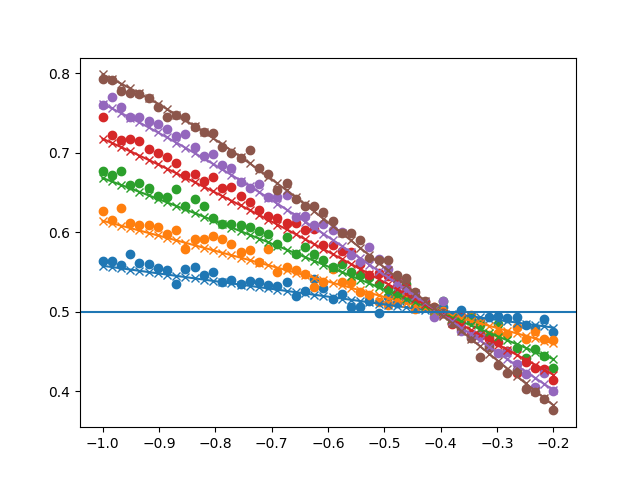

In [172]:
fig, ax = plt.subplots()

for i in range(drape_sweep_pops.shape[0]):
    ax.scatter(drape_sweep_beta, drape_sweep_pops[i][:, 2])
    # ax.plot(drape_sweep_beta, drape_sweep_pops_simulation[i])
    ax.plot(drape_sweep_beta, DRAPE_simulation_nice_unitary[i], '-x')

ax.axhline(0.5)

# D. AAE re-run

In [141]:
amp_scaled = amp_90_12_uncorrected/(1+2*0.09693166634606999/np.pi)

amp_scaled

0.2365997566232165

In [144]:
amp_scaled = amp_scaled/(1+2*0.0016808751678486084/np.pi)

amp_scaled

0.23634684697522249

In [167]:
amp_scaled = 0.23634684697522249/(1+2*-0.0020091794980787794/np.pi)

amp_scaled

0.23664954147408832

In [170]:
aae_rerun = simulateAAE(gamma=0, A0=amp_scaled, lambdas=lambdas, beta=0.40457/(2*np.pi*0.3071))

0.23664954147408832 [0.526 0.621 0.753] 0.20966888742001988


(0.0, 1.0)

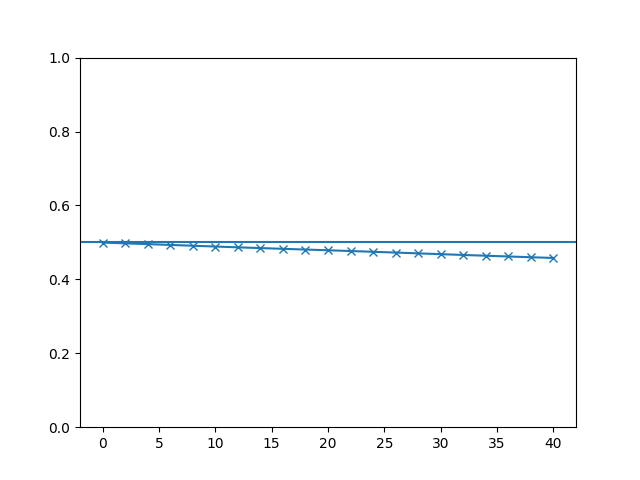

In [162]:
fig, ax = plt.subplots()

ax.axhline(0.5)
ax.plot(aae_Nvalues, aae_rerun, '-x')
ax.set_ylim(0, 1.0)

(0.0, 1.0)

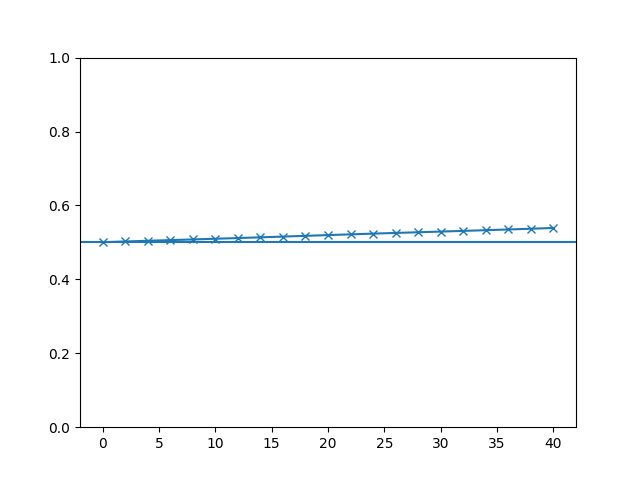

In [169]:
fig, ax = plt.subplots()

ax.axhline(0.5)
ax.plot(aae_Nvalues, aae_rerun, '-x')
ax.set_ylim(0, 1.0)

(0.0, 1.0)

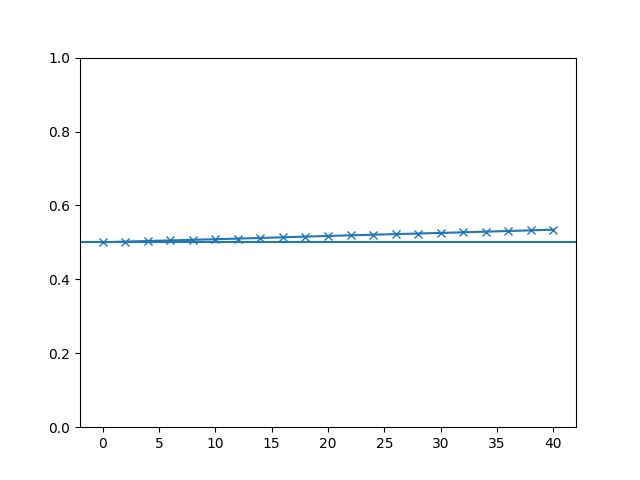

In [171]:
fig, ax = plt.subplots()

ax.axhline(0.5)
ax.plot(aae_Nvalues, aae_rerun, '-x')
ax.set_ylim(0, 1.0)